# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
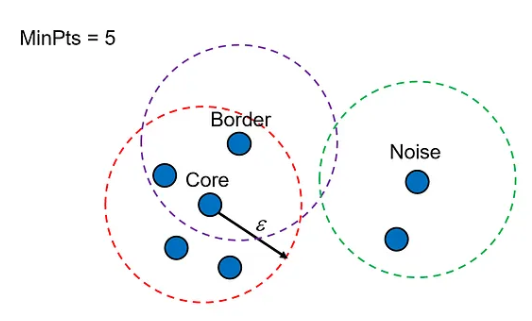

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

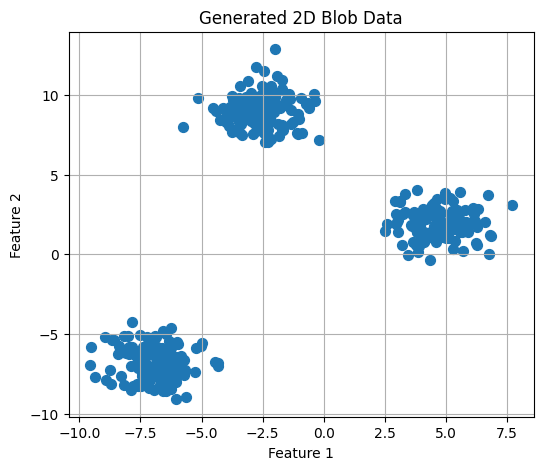

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

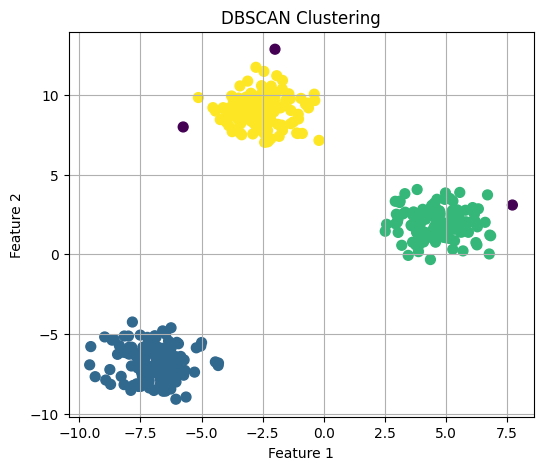

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

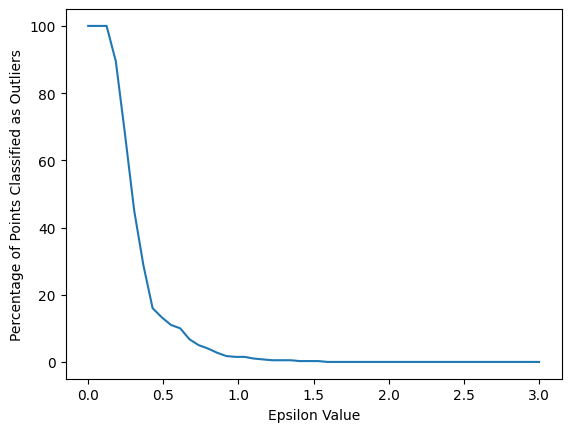

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

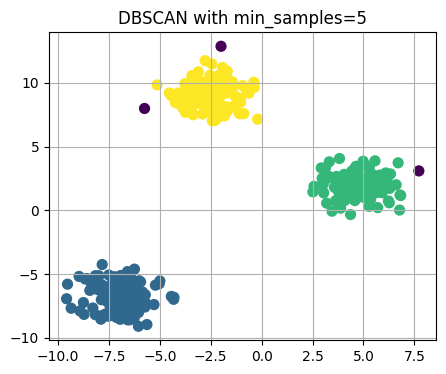

min_samples=5 → Silhouette Score: 0.848


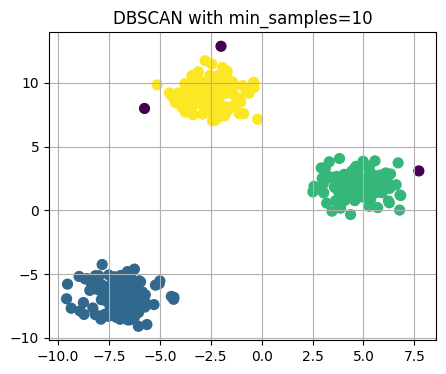

min_samples=10 → Silhouette Score: 0.848


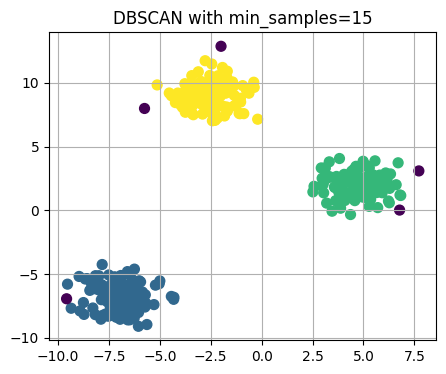

min_samples=15 → Silhouette Score: 0.849


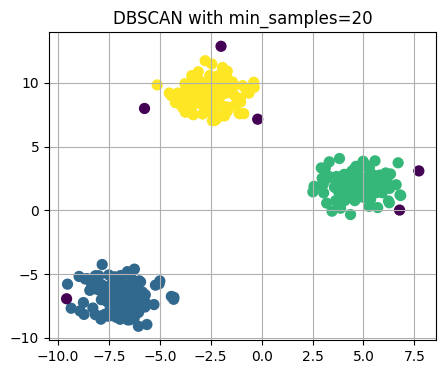

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('~/Desktop/CC GENERAL.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (8950, 18)

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nDescribe:")
df.describe()


Missing values:
 CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Duplicates: 0

Describe:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


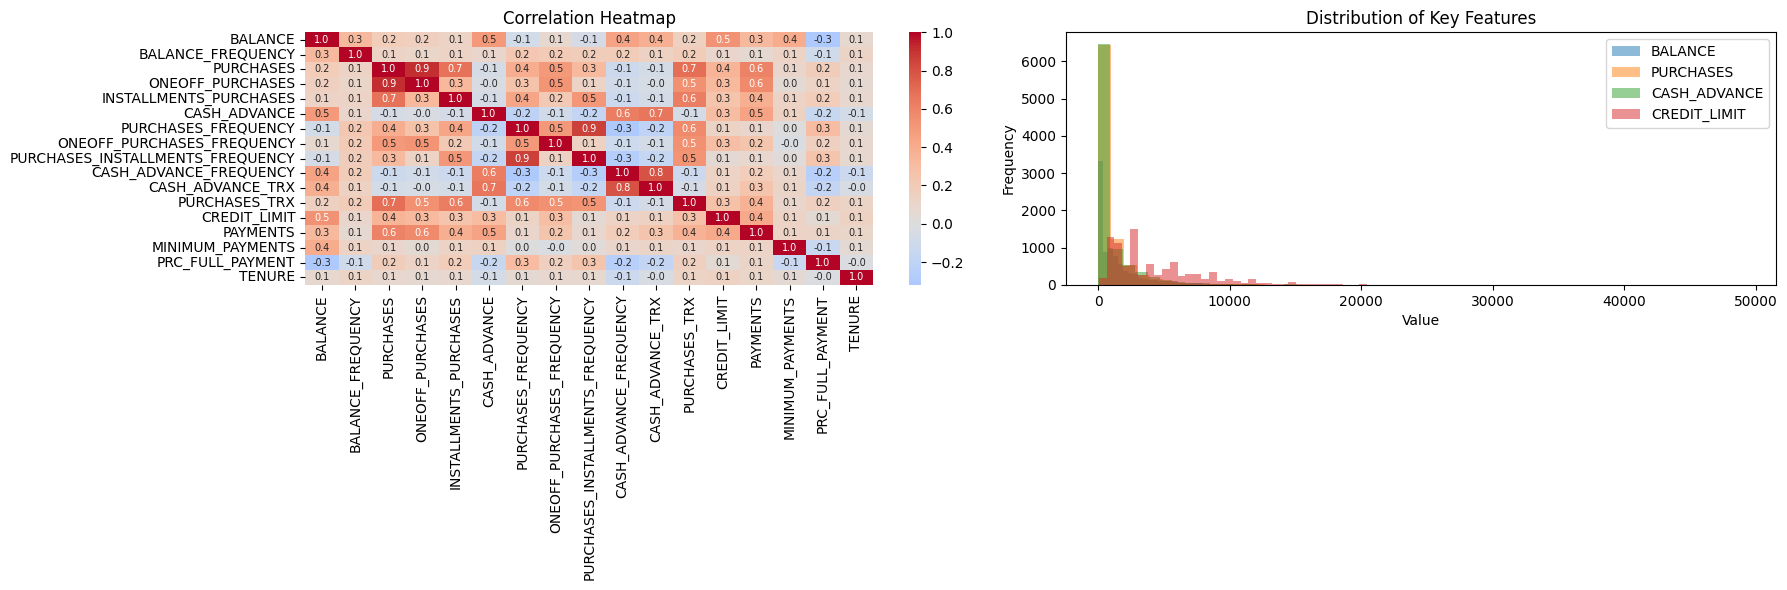

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, ax=axes[0], fmt='.1f',
            annot=True, annot_kws={'size': 7})
axes[0].set_title('Correlation Heatmap')

# Distribution of a few key features
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
for feat in features_to_plot:
    if feat in df.columns:
        axes[1].hist(df[feat].dropna(), bins=50, alpha=0.5, label=feat)
axes[1].set_title('Distribution of Key Features')
axes[1].legend()
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 2. Data Preparation

In [5]:
df_clean = df.drop(columns=['CUST_ID'], errors='ignore')

print("Missing before fill:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Fill missing with median
df_clean = df_clean.fillna(df_clean.median())

print("\nMissing after fill:\n", df_clean.isnull().sum().sum())


Missing before fill:
 CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing after fill:
 0


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Scaled data shape:", X_scaled.shape)
print("Mean (should be ~0):", X_scaled.mean(axis=0).round(2))
print("Std  (should be ~1):", X_scaled.std(axis=0).round(2))


Scaled data shape: (8950, 17)
Mean (should be ~0): [-0.  0.  0. -0.  0. -0.  0.  0.  0. -0. -0. -0.  0. -0.  0. -0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Explained variance ratio: [0.27297671 0.2031378 ]
Total explained: 47.61%


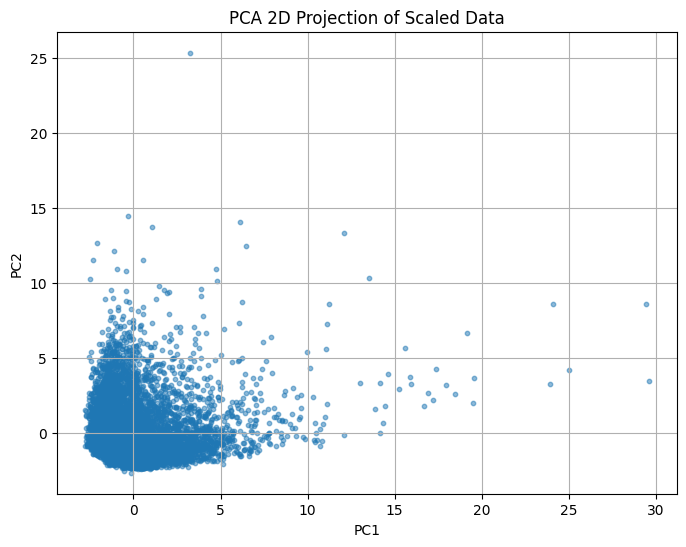

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Projection of Scaled Data')
plt.grid(True)
plt.show()


## 3. Apply DBSCAN




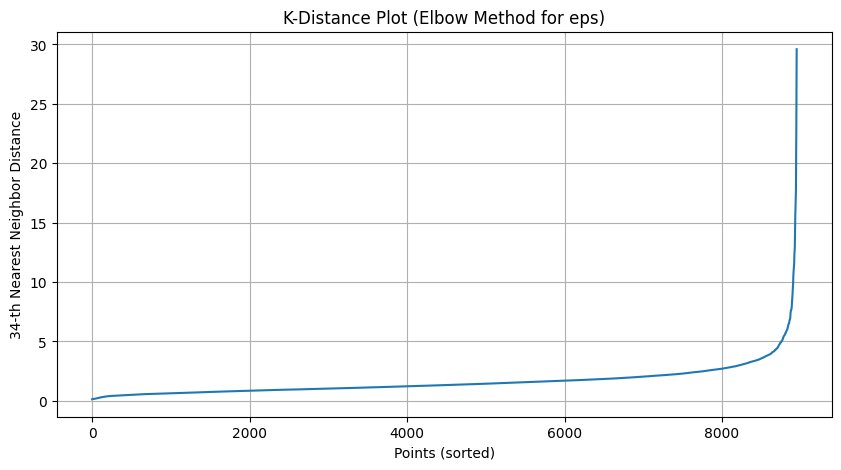

Suggested eps range: check where the curve bends sharply (elbow point)


In [8]:
from sklearn.neighbors import NearestNeighbors

k = 2 * X_scaled.shape[1]  # 2 * number of features
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distance
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Points (sorted)')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.title('K-Distance Plot (Elbow Method for eps)')
plt.grid(True)
plt.show()

# Look at the elbow region
print("Suggested eps range: check where the curve bends sharply (elbow point)")


In [23]:
from sklearn.cluster import DBSCAN

# Choose eps from the elbow plot above — adjust if needed
eps_value = 2.0
min_samples_value = 5

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value, metric='euclidean')
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"eps={eps_value}, min_samples={min_samples_value}")
print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")
print(f"Cluster distribution:\n{pd.Series(labels).value_counts().sort_index()}")


eps=2.0, min_samples=5
Number of clusters: 2
Noise points: 599 (6.7%)
Cluster distribution:
-1     599
 0    8346
 1       5
Name: count, dtype: int64


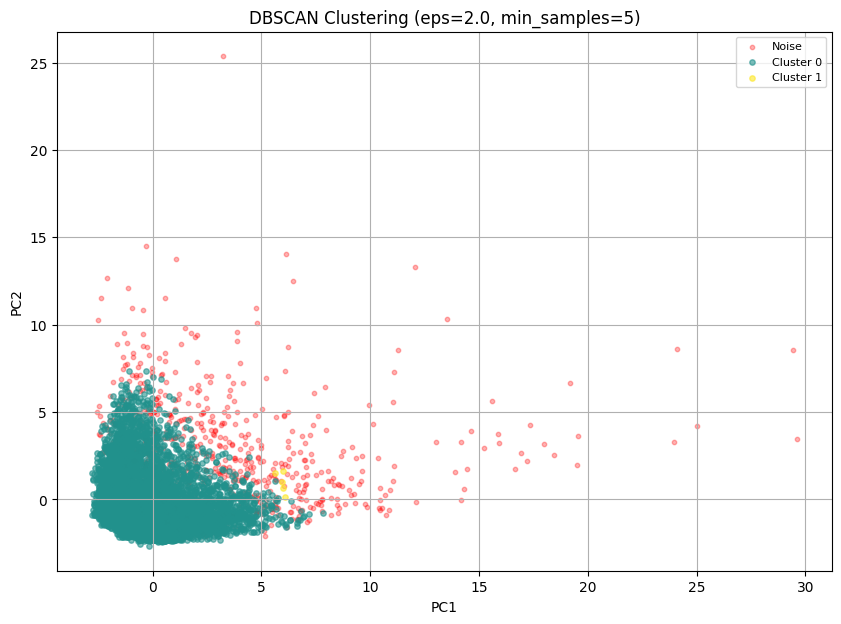

In [24]:
plt.figure(figsize=(10, 7))
unique_labels = set(labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(sorted(unique_labels), colors):
    mask = labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='red', s=10, alpha=0.3, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], s=15, alpha=0.6, label=f'Cluster {label}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN Clustering (eps={eps_value}, min_samples={min_samples_value})')
plt.legend(loc='best', fontsize=8)
plt.grid(True)
plt.show()


## 4. Evaluate the Clustering

In [25]:
from sklearn.metrics import silhouette_score

mask = labels != -1
if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {score:.4f}")
else:
    print("Not enough clusters to compute silhouette score. Try adjusting eps/min_samples.")


Silhouette Score (excluding noise): 0.4460


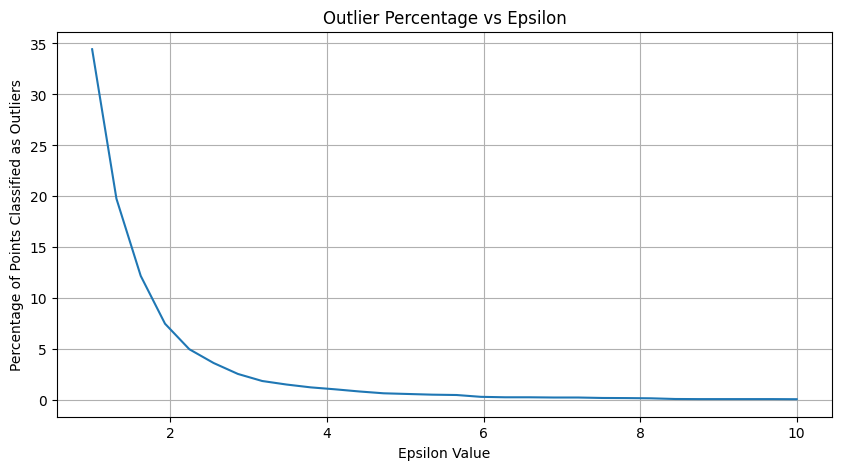

In [26]:
outlier_percent = []
eps_range = np.linspace(1, 10, 30)

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=min_samples_value)
    cluster_labels = db.fit_predict(X_scaled)
    perc = 100 * np.sum(cluster_labels == -1) / len(cluster_labels)
    outlier_percent.append(perc)

plt.figure(figsize=(10, 5))
sns.lineplot(x=eps_range, y=outlier_percent)
plt.xlabel('Epsilon Value')
plt.ylabel('Percentage of Points Classified as Outliers')
plt.title('Outlier Percentage vs Epsilon')
plt.grid(True)
plt.show()


In [28]:
print("=" * 50)
print("DBSCAN CLUSTERING SUMMARY")
print("=" * 50)
print(f"Dataset: CC GENERAL.csv")
print(f"Total samples: {len(labels)}")
print(f"Features used: {X_scaled.shape[1]}")
print(f"eps: {eps_value}, min_samples: {min_samples_value}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")
if len(set(labels[mask])) > 1:
    print(f"Silhouette Score: {score:.4f}")
print("=" * 50)


DBSCAN CLUSTERING SUMMARY
Dataset: CC GENERAL.csv
Total samples: 8950
Features used: 17
eps: 2.0, min_samples: 5
Clusters found: 2
Noise points: 599 (6.7%)
Silhouette Score: 0.4460
